In [1]:
# import os
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import sys
sys.path.append('../')

import superstats as sup
import bayesflow as bf
import numpy as np

import jax

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## Constants

In [3]:
NUM_STEPS = 100
NUM_SAMPLES = 500
NUM_EPOCHS = 100
NUM_ITER_PER_EPOCH = 1000
BATCH_SIZE = 32

## Prior

In [4]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(0.0, 6.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    a = sup.transition.RandomWalk(
            bounds=(0.0, 4.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=0.0, scale=0.5)
        ),
    tau = sup.transition.RandomWalk(
            bounds=(0.0, 2.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    bias = 0.5
)

ddm = sup.simulation.sample_ddm

generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=ddm,
)

/home/radevs/anaconda3/envs/bfjax/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


## Workflow

In [5]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    summary_network=sup.networks.RecurrentNet(
        hidden_dim=(32, 128)
    )
)

/tmp/ipykernel_104791/3932162231.py:1: UserWarning: restore_approximator=True but no model found at 'None'. Starting with no trained model.
  workflow = sup.workflow.Workflow(
/tmp/ipykernel_104791/3932162231.py:1: UserWarning: restore_history=True but no history found at 'None'. Starting with no history.
  workflow = sup.workflow.Workflow(


## Training

In [6]:
training_data = generative_model.sample(10_000, num_steps=NUM_STEPS, tile_to_steps=True)
val_data = generative_model.sample(100, num_steps=NUM_STEPS, tile_to_steps=True)

In [7]:
history = workflow.fit_offline(
    data=training_data,
    validation_data=val_data,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - loss: -0.7895 - val_loss: -1.4924
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: -1.7199 - val_loss: -2.3014
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: -2.4407 - val_loss: -2.6393
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: -2.6123 - val_loss: -2.7236
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: -2.6719 - val_loss: -2.7582
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: -2.7051 - val_loss: -2.7699
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: -2.7260 - val_loss: -2.7831
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: -2.7310 - val_loss: -2.8024
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: -2.7375 - val_loss: -2.7679
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: -2.7390 - val_loss: -2.7633
Epoch 11/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: -2.7450 - val_loss: -2.8014
Epoch 1

INFO:bayesflow:Training completed in 11.30 minutes.


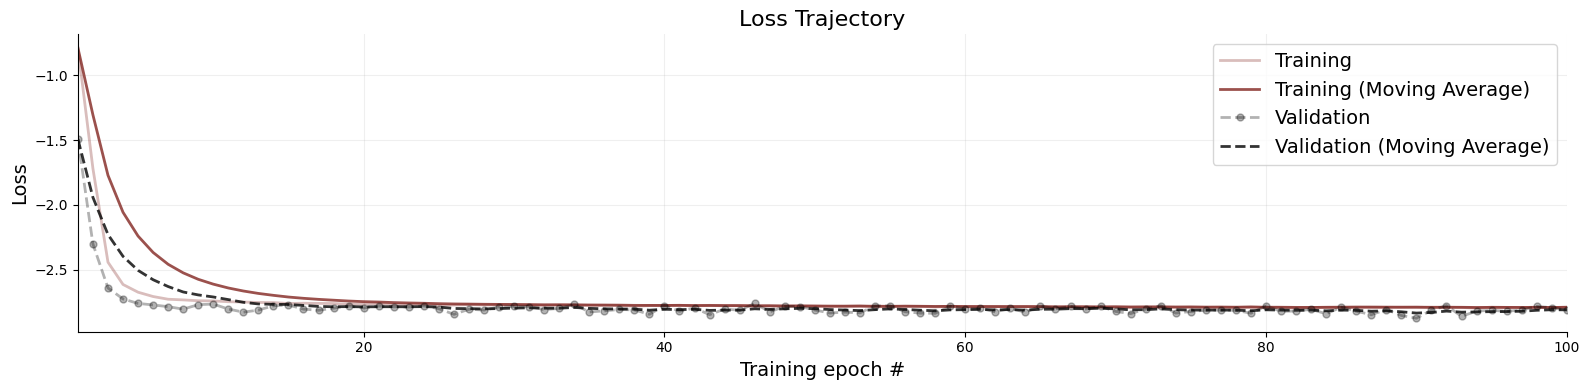

In [8]:
fig = workflow.plot_history(workflow.history)

## Verification

In [9]:
val_data = workflow.simulator.sample(
    batch_size=500,
    num_steps=NUM_STEPS
)

In [19]:
samples = workflow.sample(
    data=val_data['data'],
    num_samples=NUM_SAMPLES,
    inference_batch_size=4
)

Summarizing:   0%|          | 0/125 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/125 [00:00<?, ?batch/s]

### Time-varying Parameters

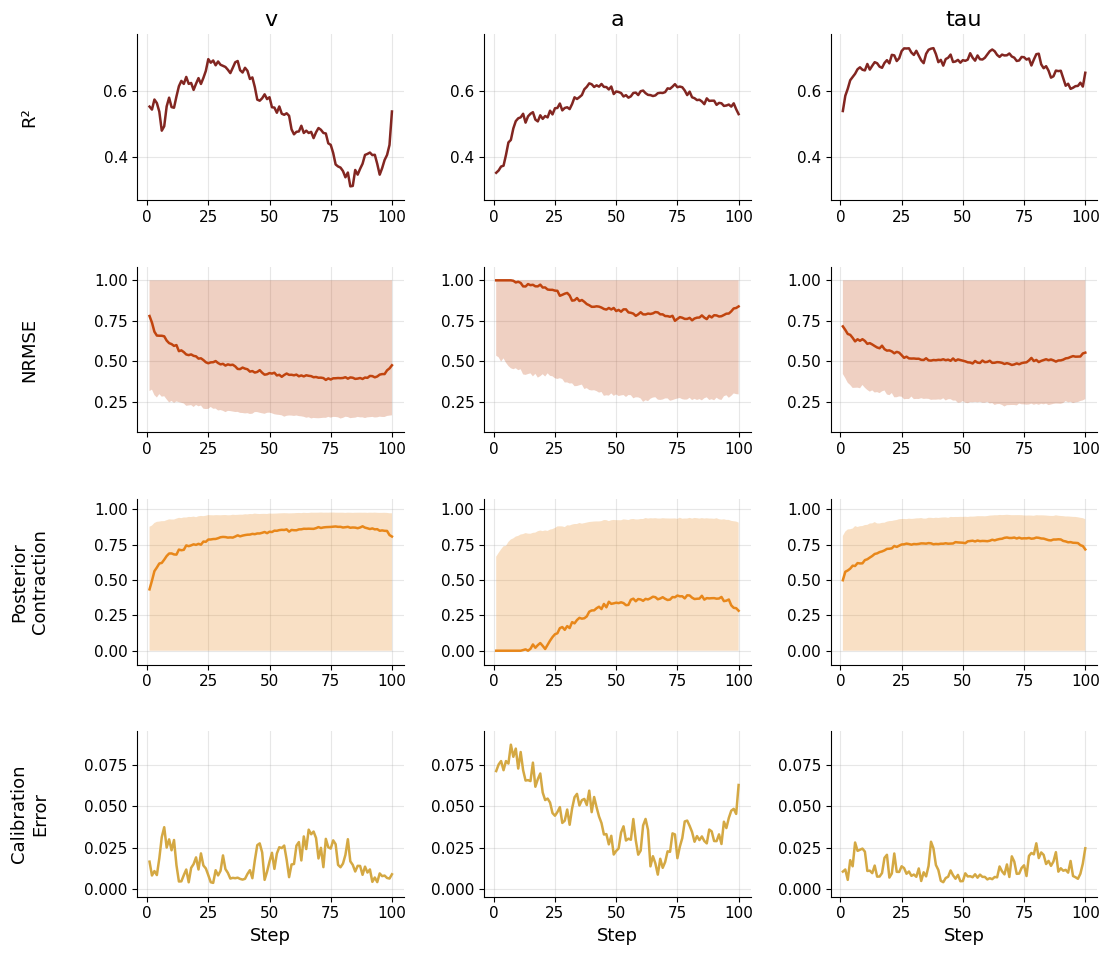

In [12]:
fig = workflow.verify_time_varying(val_data, samples)

In [16]:
time_step = 99
local_keys = workflow.simulator.local_keys
true = np.stack([val_data[k][:, time_step, 0] for k in local_keys], axis=-1)
estimates = np.stack([samples[k][:, :, time_step, 0] for k in local_keys], axis=-1)

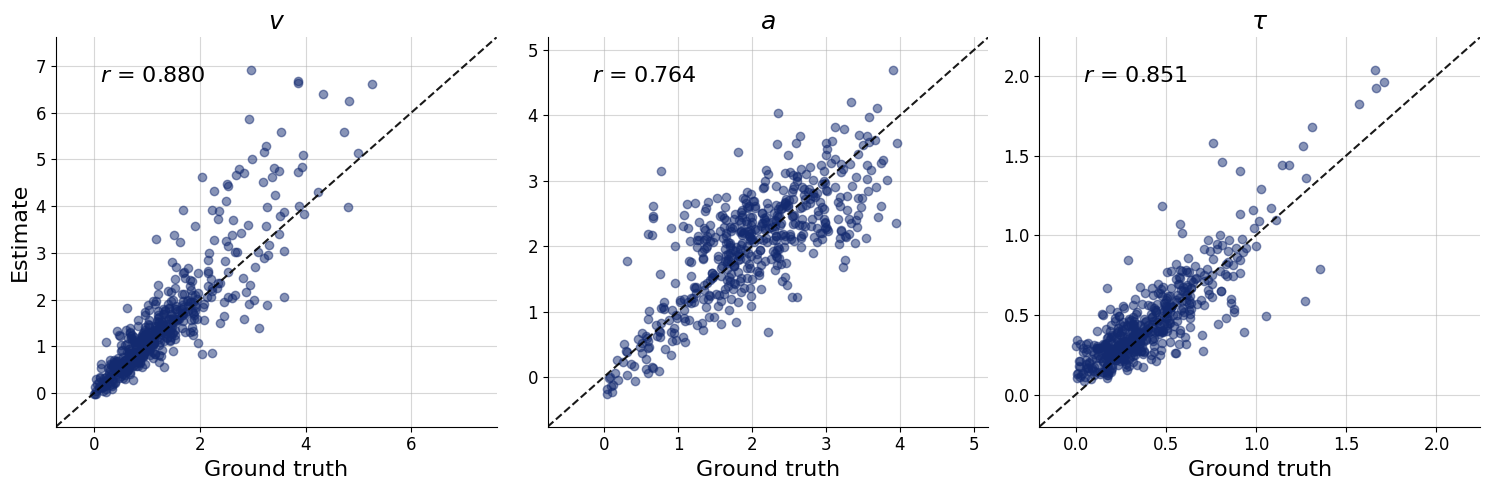

In [17]:
fig = bf.diagnostics.plots.recovery(
    estimates,
    true,
    variable_names = [r"$v$", r"$a$", r"$\tau$"],
    uncertainty_agg=None
)

### Time-invariant Parameters

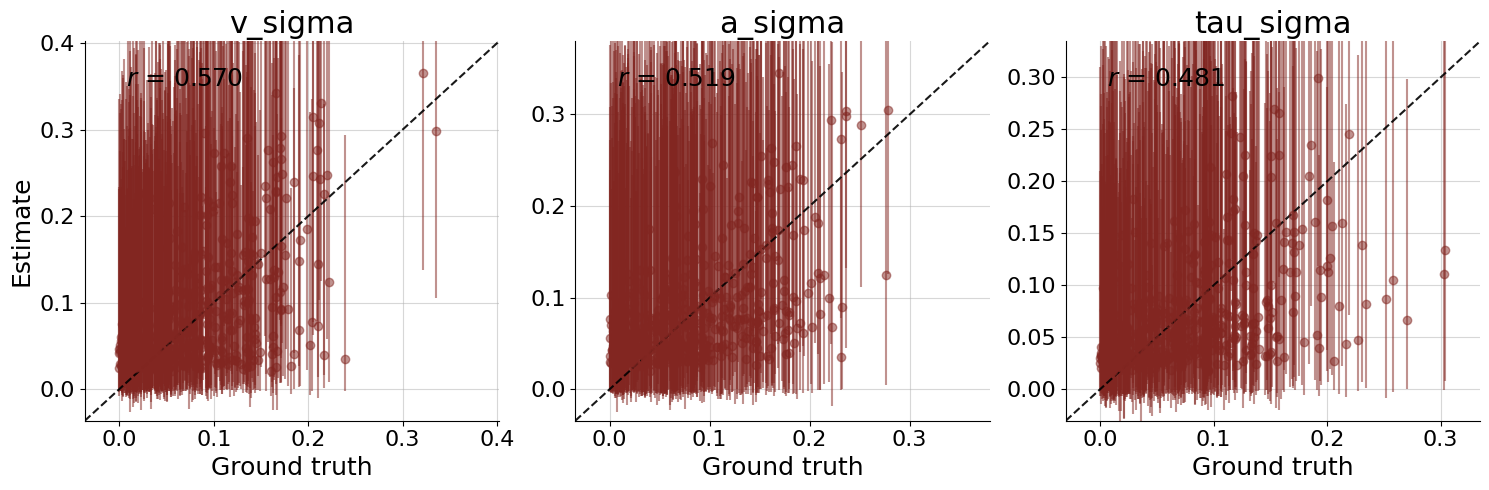

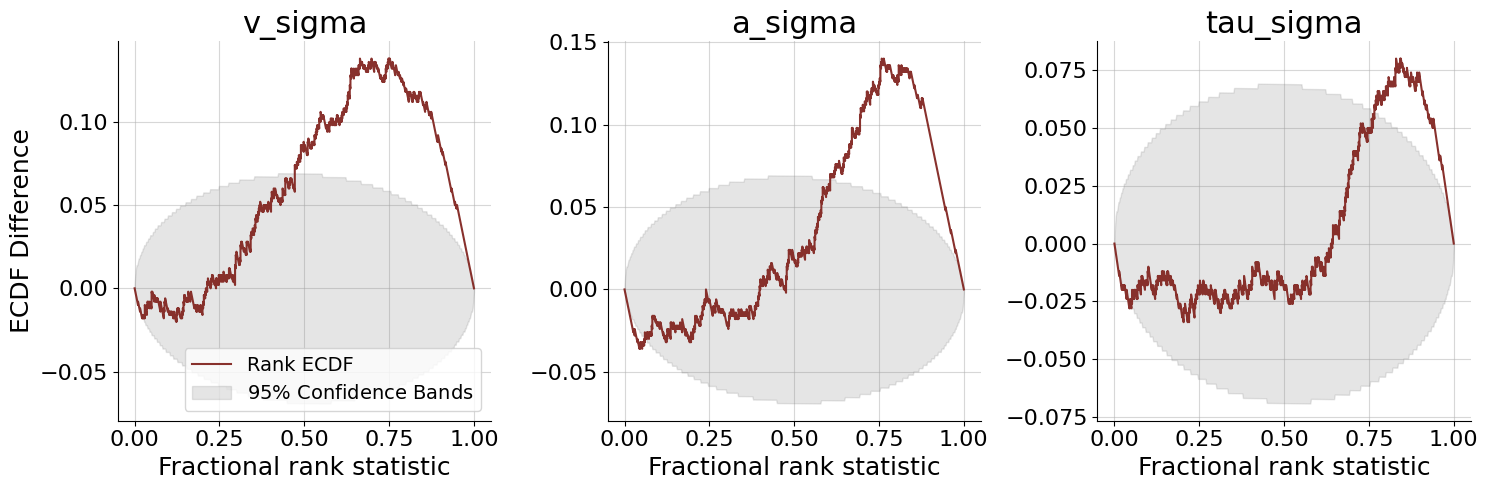

In [18]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    val_data,
    samples
)